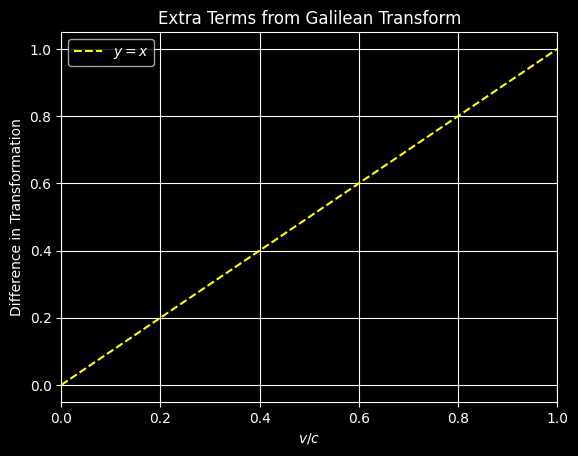

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Set up the velocity range from 0 to 1
v_over_c = np.linspace(0, 1, 500)

# Add the y = x line
plt.plot(v_over_c, v_over_c, label='$y = x$', color='yellow', linestyle='--')

# Labels and title
plt.xlabel('$v/c$')
plt.ylabel('Difference in Transformation')
plt.title('Extra Terms from Galilean Transform')

# Set axis limits
plt.xlim(0, 1)

# Grid and legend
plt.grid(True)
plt.legend()

# Show the plot
#plt.savefig("extra galiliean terms.png",dpi=500)
plt.show()

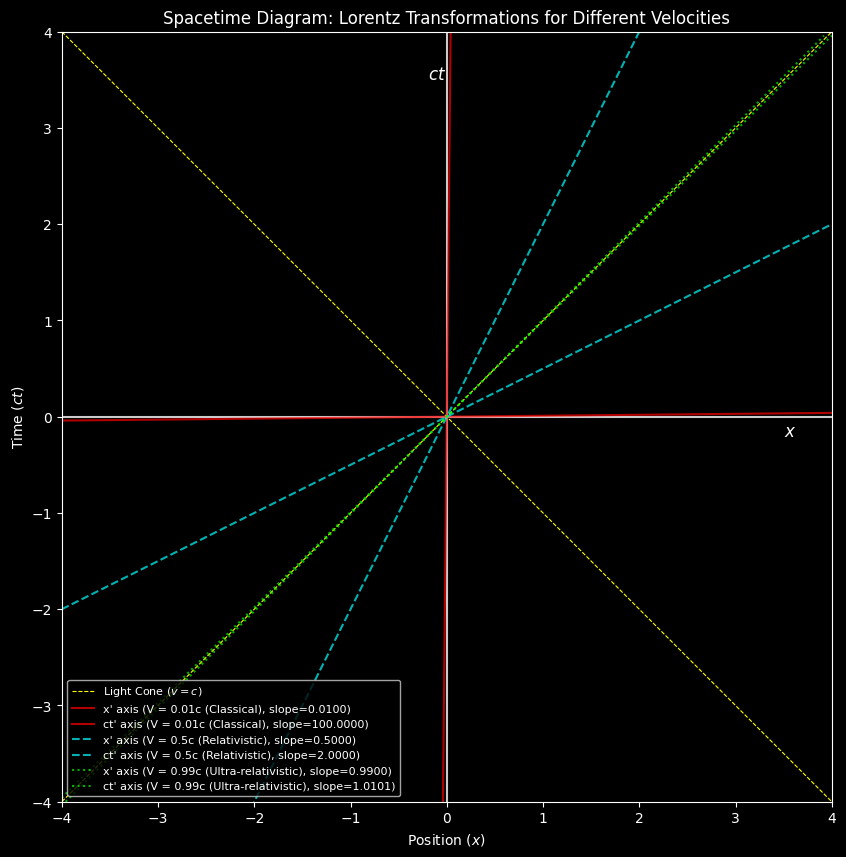

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define the Velocities (in units of c) ---
# We will plot the axes for three different velocities:
velocities = {
    'V = 0.01c (Classical)': 0.01,
    'V = 0.5c (Relativistic)': 0.5,
    'V = 0.99c (Ultra-relativistic)': 0.99
}

# --- Plotting Setup ---
def plot_spacetime_diagram(v, label, color, linestyle='-'):
    """
    Calculates and plots the Lorentz-transformed x' and ct' axes for a given velocity v.
    """
    
    # 1. Calculate Gamma Factor
    # Gamma (γ) = 1 / sqrt(1 - (v/c)^2). Since we use v in units of c, (v/c) -> v.
    gamma = 1 / np.sqrt(1 - v**2)
    
    # 2. Determine Slopes of the Transformed Axes
    # The x' axis is where t' = 0, which gives the equation: T = (v/c) * X, so the slope is v.
    # The ct' axis is where x' = 0, which gives the equation: T = (c/v) * X, so the slope is 1/v.
    slope_x_prime = v
    slope_ct_prime = 1 / v
    
    # Create the x-coordinates for plotting the lines
    X_coords = np.linspace(-4, 4, 100)
    
    # 3. Plot the x' axis (line of simultaneous events, t' = 0)
    T_x_prime = slope_x_prime * X_coords
    plt.plot(X_coords, T_x_prime, color=color, linestyle=linestyle, alpha=0.7,
             label=f"x' axis ({label}, slope={slope_x_prime:.4f})")
    
    # 4. Plot the ct' axis (worldline of the moving origin, x' = 0)
    # The worldline for the ct' axis is usually only plotted in the forward time direction (T > 0)
    T_ct_prime = slope_ct_prime * X_coords
    
    # Restrict to the visible range for clarity, but plot the whole line segment
    start_index = np.where(X_coords >= -4)[0][0]
    end_index = np.where(X_coords <= 4)[0][-1]

    plt.plot(
        X_coords[start_index:end_index], T_ct_prime[start_index:end_index], 
        color=color, linestyle=linestyle, alpha=0.7, 
        label=f"ct' axis ({label}, slope={slope_ct_prime:.4f})"
    )


# --- Initialization of Plot and Stationary Frame ---
plt.figure(figsize=(10, 10))
plt.style.use('dark_background') # Nice aesthetic for spacetime diagrams

# Set Axis Limits and Labels
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel("Position ($x$)")
plt.ylabel("Time ($ct$)")
plt.title("Spacetime Diagram: Lorentz Transformations for Different Velocities")

# Plot Stationary Frame (x and ct axes)
plt.axhline(0, color='white', linewidth=1.5, alpha=0.8) # x-axis (T=0)
plt.axvline(0, color='white', linewidth=1.5, alpha=0.8) # ct-axis (X=0)
plt.text(3.5, -0.2, '$x$', color='white', fontsize=12)
plt.text(-0.2, 3.5, '$ct$', color='white', fontsize=12)


# Plot the Light Cone (The absolute limit, slope = ±1)
X_light = np.linspace(-4, 4, 100)
plt.plot(X_light, X_light, color='yellow', linestyle='--', linewidth=0.8, label="Light Cone ($v=c$)")
plt.plot(X_light, -X_light, color='yellow', linestyle='--', linewidth=0.8)


# --- Plotting the Moving Frames ---
colors = ['red', 'cyan', 'lime']
styles = ['-', '--', ':']

for (label, v), color, style in zip(velocities.items(), colors, styles):
    plot_spacetime_diagram(v, label, color, style)

# Add Legend and Show Plot
plt.legend(loc='lower left', fontsize=8)
plt.gca().set_aspect('equal', adjustable='box') # Ensures T=X diagonal is at 45 degrees
#plt.savefig("Hyperbolic rotations in space-time.png",dpi=500)
plt.show()

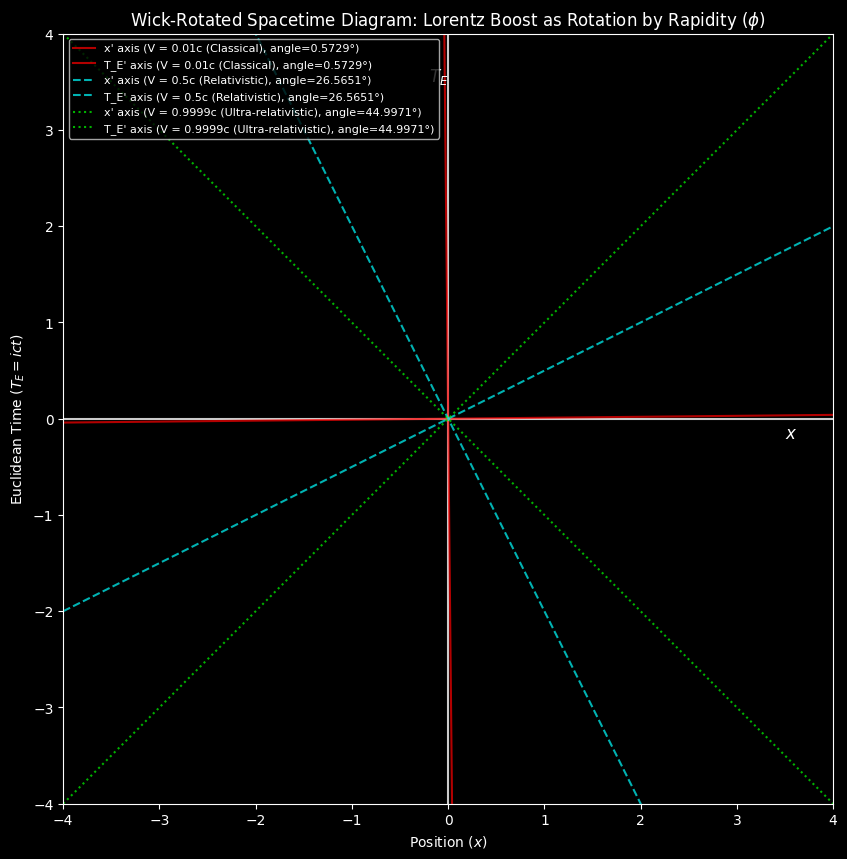

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define the Velocities (in units of c) ---
# We will plot the axes for three different velocities:
velocities = {
    'V = 0.01c (Classical)': 0.01,
    'V = 0.5c (Relativistic)': 0.5,
    'V = 0.9999c (Ultra-relativistic)': 0.9999
}

# --- Plotting Setup ---
def plot_wick_rotated_diagram(v, label, color, linestyle='-'):
    """
    Calculates and plots the Euclidean-transformed x' and T_E' axes for a given velocity v.
    
    In Wick-rotated space, the Lorentz boost is equivalent to an ordinary rotation
    by an angle equal to the rapidity, phi (φ).
    """
    
    # 1. Calculate the Rapidity (phi)
    # Rapidity (φ) = arctanh(v/c). This is the correct angle for the circular rotation.
    phi = np.arctan(v)
    
    # The rotation angle theta is equal to the rapidity phi
    theta = phi
    
    # The axes are rotated by this angle (theta) relative to the stationary T_E and x axes.
    # The unprimed axes are defined by T_E and x.
    
    # Create the coordinate range
    R_max = 4 # Max radius for the axes lines
    R_coords = np.linspace(-R_max, R_max, 100)
    
    # Slope of x' axis (T_E vs x)
    # T_E = x * tan(theta)
    slope_x_prime = np.tan(theta)
    
    # Slope of T_E' axis (T_E vs x)
    # T_E = -x * cot(theta)
    slope_t_prime = -1 / slope_x_prime
    
    # 3. Plot the x' axis 
    T_x_prime = slope_x_prime * R_coords
    plt.plot(R_coords, T_x_prime, color=color, linestyle=linestyle, alpha=0.7,
             label=f"x' axis ({label}, angle={np.degrees(theta):.4f}°)")
    
    # 4. Plot the T_E' axis (Orthogonal to x' axis)
    T_t_prime = slope_t_prime * R_coords
    
    plt.plot(R_coords, T_t_prime, color=color, linestyle=linestyle, alpha=0.7, 
             label=f"T_E' axis ({label}, angle={np.degrees(theta):.4f}°)")

# --- Initialization of Plot and Stationary Frame ---
plt.figure(figsize=(10, 10))
plt.style.use('dark_background') 

# Set Axis Limits and Labels
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel("Position ($x$)")
plt.ylabel("Euclidean Time ($T_E = ic t$)")
plt.title("Wick-Rotated Spacetime Diagram: Lorentz Boost as Rotation by Rapidity ($\\phi$)")

# Plot Stationary Frame (x and T_E axes) - they are orthogonal in Euclidean space
plt.axhline(0, color='white', linewidth=1.5, alpha=0.8) # x-axis
plt.axvline(0, color='white', linewidth=1.5, alpha=0.8) # T_E-axis
plt.text(3.5, -0.2, '$x$', color='white', fontsize=12)
plt.text(-0.2, 3.5, '$T_E$', color='white', fontsize=12)

# --- Plotting the Moving Frames ---
colors = ['red', 'cyan', 'lime']
styles = ['-', '--', ':']

for (label, v), color, style in zip(velocities.items(), colors, styles):
    # Only plot if v is not c
    if v < 1.0:
        plot_wick_rotated_diagram(v, label, color, style)

# Add Legend and Show Plot
plt.legend(loc='upper left', fontsize=8)
plt.gca().set_aspect('equal', adjustable='box') # Ensures axes are square
#plt.savefig("Circular rotations in space-Euclidean_time.png",dpi=500)
plt.show()

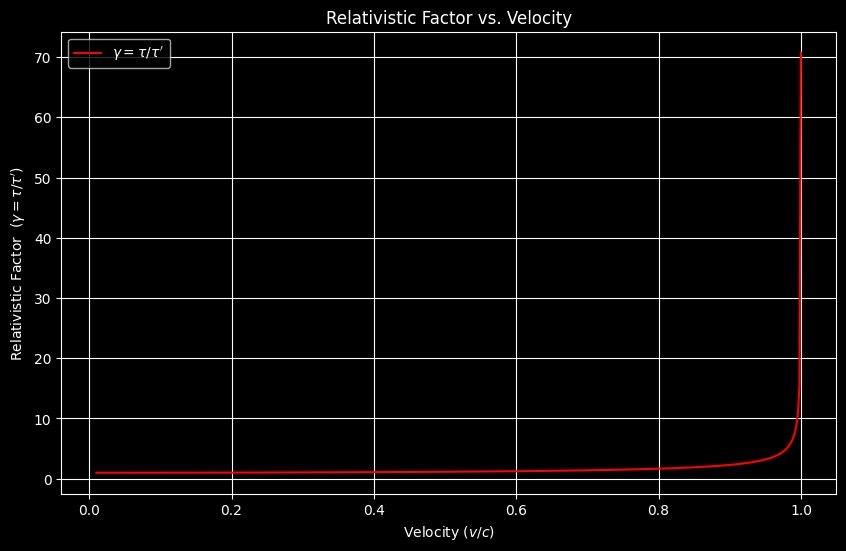

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Set up the velocity range from 0.01c to 0.9999c
v_over_c = np.linspace(0.01, 0.9999, 500)

# Calculate the gamma factor for each velocity
gamma = 1 / np.sqrt(1 - v_over_c**2)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(v_over_c, gamma, label='$\\gamma = \\tau/\\tau^\\prime$',color='red')
plt.xlabel('Velocity ($v/c$)')
plt.ylabel('Relativistic Factor  ($\\gamma = \\tau/\\tau^\\prime$)')
plt.title('Relativistic Factor vs. Velocity')
plt.grid(True)
plt.legend()
#plt.savefig("Gamma factor.png",dpi=500)
plt.show()